# Historical bias: coarse debiased vs. downscaled debiased vs. observations

**The goal of this notebook is to identify places where the spatial disaggregation (i.e., downscaling) step is hurting rather than helping.** Markdown text was generated with Claude based on rough notes and interview questions, then edited manually.

For a single historical variable/scenario/ensemble member, we compare how well the **coarse debiased** output and the **downscaled, debiased** compare to observations (ERA5) -- both at ERA5's native (fine) resolution and coarsened to the model's grid.

The entire point of downscaling is to add back fine-scale detail that debiasing at coarse resolution can't capture. So we expect:
- **Downscaled should beat coarse debiased when compared to fine-resolution obs.** This is the core test -- we expect downscaling to make data look better when compared to fine-resolution observations. If the **coarse** product looks better than the **downscaled** product in either comparison, that's a red flag: it means downscaling is making things worse, not better.
- **Downscaled should ideally also beat coarse when both are compared to coarsened obs**, though this is a weaker requirement -- some quality loss from spatially averaging a higher-resolution product is expected and less concerning.

We measure "how well X reproduces obs" with an R² relative to the 1:1 line (Nash-Sutcliffe efficiency), computed on a **monthly (or smoothed day-of-year) climatology** rather than raw daily values. Precipitation is intermittent and event-driven, and this is a free-running historical simulation (not reanalysis nudged to match real-world weather) -- there's no reason a storm should land on the same calendar date in the model as in ERA5, even for a very good model. Comparing at raw daily resolution double-penalizes any timing offset (missed on the right day + false alarm on the wrong day), which drowns out the real seasonal-cycle signal. Averaging over a month, or smoothing over a rolling window of days, suppresses that timing noise and isolates genuine seasonal-cycle skill.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import pandas as pd

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import disagg_test_calculate_metrics
from srm.utils import open_icechunk

## Configuration

Settings below are specific to this variable/scenario/ensemble member and this machine's output paths. Update these to rerun for a different variable or dataset.

In [2]:
# --- Data source ---
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"

# --- Variable / scenario / ensemble member ---
var = "pr"
scenario = "historical"
ens = "r3i1p1f1"

# --- Plot color scales ---
# r2_oneone (NSE) tops out at 1 (perfect); values below 0 all mean "worse than
# just using the observed mean," so we don't need color resolution below 0.
r2_vmin, r2_vmax = 0.7, 1.0
# vmax for (downscaled r2 - coarse r2) difference maps -- both the diverging
# map and the "where does downscaling win/lose" split maps. Fixed for now;
# revisit once you've seen the actual post-fix, monthly-scale values.
r2_diff_vmax = 0.3

# --- Colorbar labels ---
# The maps below plot r2_oneone or a difference of r2_oneone, not the raw
# variable -- set these explicitly so the colorbar doesn't fall back to
# whatever `units` attr (e.g. "mm/day") happened to survive the arithmetic.
r2_label = "r2_oneone (NSE)"
r2_diff_label = "Δ r2_oneone (downscaled − coarse)"

# --- Climatology aggregation method ---
# "month"     -> groupby calendar month (recommended default; see markdown
#                discussion above for why not raw daily/day-of-year values)
# "dayofyear" -> groupby day-of-year, then a centered, circular rolling-mean
#                smoother (window = rolling_window_days) to damp day-to-day
#                storm-timing noise while keeping more within-season detail
#                than monthly
time_dim = "month"  # note "dayofyear" option is very slow
rolling_window_days = 30  # only used when time_dim == "dayofyear"

## Load data

In [3]:
repo = icechunk.Repository.open(
    icechunk.s3_storage(
        bucket="carbonplan-srm",
        prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
        region="us-west-2",
    )
)
print("Available branches:", repo.list_branches())
assert branch in repo.list_branches(), f"branch {branch!r} not found"

Available branches: {'v0.7.0', 'v0.8.0', 'v0.11.1', 'v0.11.0', 'v0.10.0', 'main'}


In [4]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]

debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [5]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

## Regrid onto matching resolutions

To isolate the effect of downscaling from the effect of resolution mismatch, we build four combinations:

| | vs. fine obs | vs. coarse obs |
|---|---|---|
| **coarse debiased output** | upsampled to fine grid (nearest-neighbor) | native |
| **downscaled, debiased output** | native | coarsened to match obs |

Comparing at both resolutions lets us separate two questions: does downscaling look better against real fine-scale detail (the resolution obs are actually observed at), and does it hold up even after that fine detail is averaged away again?

In [6]:
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()
coarse_debiased_finegrid = coarse_debiased.interp(
    lon=obs_fine["lon"],
    lat=obs_fine["lat"],
    method="nearest",
).compute()

fine = rechunk(
    debiased_downscaled, pattern="full_space"
).persist()  # -> (time≈25, lat=-1, lon=-1), ~100 MB/chunk
coarsened_debiased_downscaled = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine, da_coarse_grid=coarse_debiased
).compute()

## Compute climatology & goodness-of-fit metrics

For each grid cell, we collapse the historical time series to a climatology before comparing to obs. The method is set by `time_dim` in Configuration above:
- `"month"` (default): mean by calendar month. See the timescale discussion at the top of the notebook for why this is recommended over raw daily/day-of-year values.
- `"dayofyear"`: mean by calendar day, then a centered, circular `rolling_window_days`-wide rolling mean. Keeps more within-season resolution than monthly while still damping day-to-day storm-timing noise.

We use `r2_oneone`: an R² relative to the 1:1 line (Nash-Sutcliffe efficiency), treating obs as ground truth. It's 1 for a perfect match, 0 if the product is no better than just guessing the observed mean, and can go negative if it's worse than that.

In [7]:
def agg_over_time(da, time_dim, rolling_window_days=10):
    """Climatology of da, grouped by time_dim ("month" or "dayofyear").

    For "dayofyear", also applies a centered rolling-mean smoother (window =
    rolling_window_days) to damp single-day storm-timing noise, wrapping
    across the Dec 31 / Jan 1 boundary so the smoothing is circular.
    """
    da_agg = da.groupby("time." + time_dim).mean().compute()
    if time_dim == "dayofyear":
        dayofyear = da_agg["dayofyear"]
        n = da_agg.sizes["dayofyear"]
        half = rolling_window_days // 2
        da_agg = da_agg.pad(dayofyear=half, mode="wrap")
        da_agg = da_agg.rolling(dayofyear=rolling_window_days, center=True, min_periods=1).mean()
        da_agg = da_agg.isel(dayofyear=slice(half, half + n))
        da_agg = da_agg.assign_coords(dayofyear=dayofyear)
    return da_agg

In [8]:
# Two outputs on the fine grid
debiased_downscaled_clim = agg_over_time(
    debiased_downscaled, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()
coarse_debiased_finegrid_clim = agg_over_time(
    coarse_debiased_finegrid, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()

# Two outputs on the coarse grid
coarse_debiased_clim = agg_over_time(
    coarse_debiased, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()
coarsened_debiased_downscaled_clim = agg_over_time(
    coarsened_debiased_downscaled, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()

obs_fine_clim = agg_over_time(
    obs_fine, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()
obs_coarse_clim = agg_over_time(
    obs_coarse, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()

metrics_obsfine_outputfine = disagg_test_calculate_metrics(
    x=obs_fine_clim, y=debiased_downscaled_clim, time_dim=time_dim
)
metrics_obsfine_outputcoarse = disagg_test_calculate_metrics(
    x=obs_fine_clim, y=coarse_debiased_finegrid_clim, time_dim=time_dim
)

metrics_obscoarse_outputfine = disagg_test_calculate_metrics(
    x=obs_coarse_clim, y=coarsened_debiased_downscaled_clim, time_dim=time_dim
)
metrics_obscoarse_outputcoarse = disagg_test_calculate_metrics(
    x=obs_coarse_clim, y=coarse_debiased_clim, time_dim=time_dim
)

## Map r2_oneone (NSE) across all grid cells

- **(A)** and **(B)**: fine obs vs. fine (downscaled) output, and fine obs vs. coarse output upsampled to the fine grid -- the primary comparison, since it's against real observed spatial detail.
- **(D)** and **(E)**: the same comparison, but with obs and the downscaled output both coarsened to the model's native grid.
- **(A)-(B)** and **(D)-(E)**: downscaled minus coarse. Blue = downscaling helps; red = downscaling hurts.

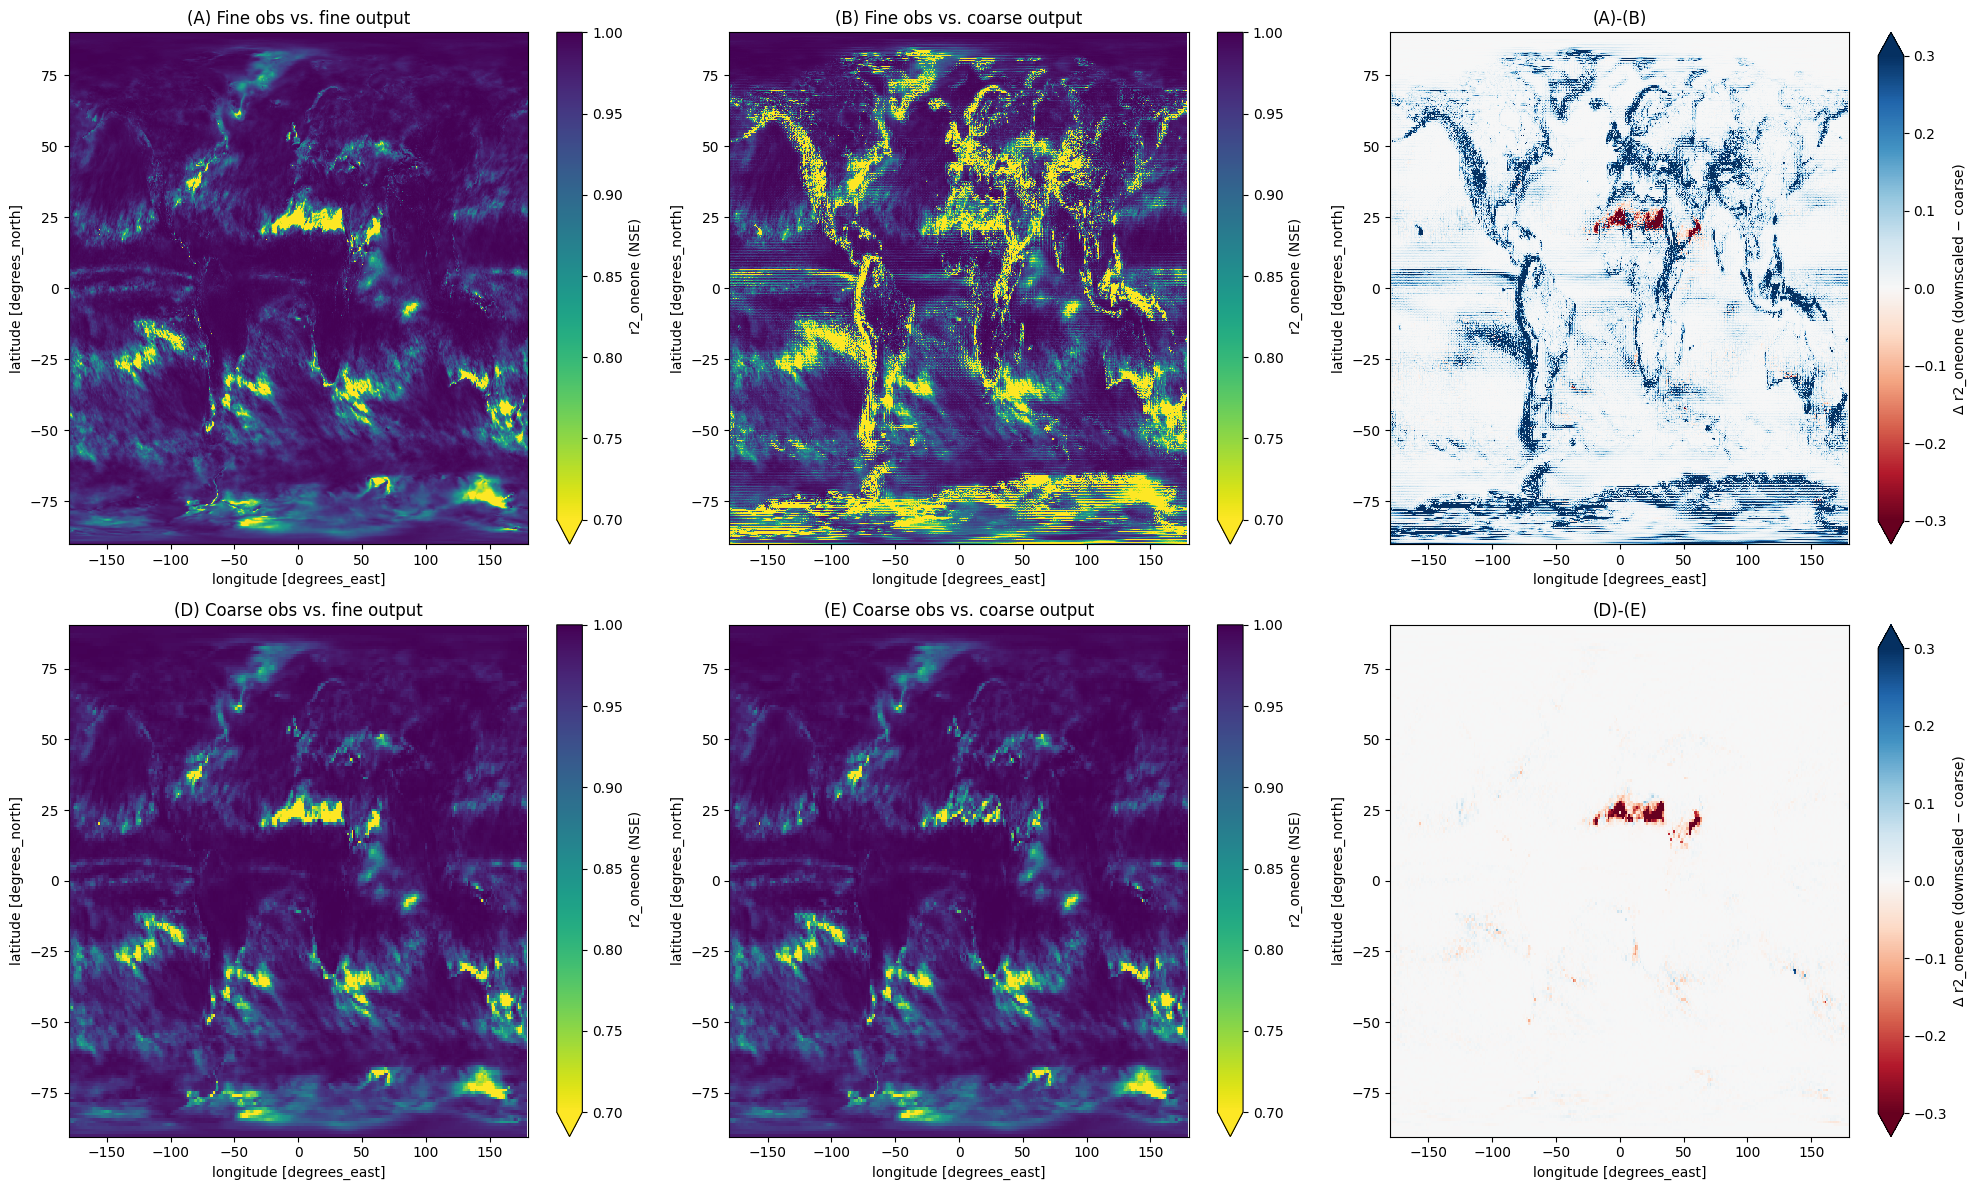

In [9]:
def format_subplot():
    plt.xlim([-180, 180])


plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1)
metrics_obsfine_outputfine["r2_oneone"].plot(
    vmin=r2_vmin, vmax=r2_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": r2_label}
)
plt.title("(A) Fine obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 2)
metrics_obsfine_outputcoarse["r2_oneone"].plot(
    vmin=r2_vmin, vmax=r2_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": r2_label}
)
plt.title("(B) Fine obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 3)
(metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]).plot(
    vmin=-r2_diff_vmax, vmax=r2_diff_vmax, cmap=plt.cm.RdBu, cbar_kwargs={"label": r2_diff_label}
)
plt.title("(A)-(B)")
format_subplot()
plt.subplot(2, 3, 4)
metrics_obscoarse_outputfine["r2_oneone"].plot(
    vmin=r2_vmin, vmax=r2_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": r2_label}
)
plt.title("(D) Coarse obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 5)
metrics_obscoarse_outputcoarse["r2_oneone"].plot(
    vmin=r2_vmin, vmax=r2_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": r2_label}
)
plt.title("(E) Coarse obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 6)
(metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]).plot(
    vmin=-r2_diff_vmax, vmax=r2_diff_vmax, cmap=plt.cm.RdBu, cbar_kwargs={"label": r2_diff_label}
)
plt.title("(D)-(E)")
format_subplot()
plt.tight_layout()
plt.savefig(path_qaqc + "hist_bias_maps_" + var + "_" + scenario + "_" + ens + ".png")

## Where exactly does downscaling help vs. hurt?

Same (downscaled − coarse) difference as above, but split into two panels per comparison so the sign is unambiguous: left = downscaling wins, right = downscaling loses. Gray = the other sign (masked out).

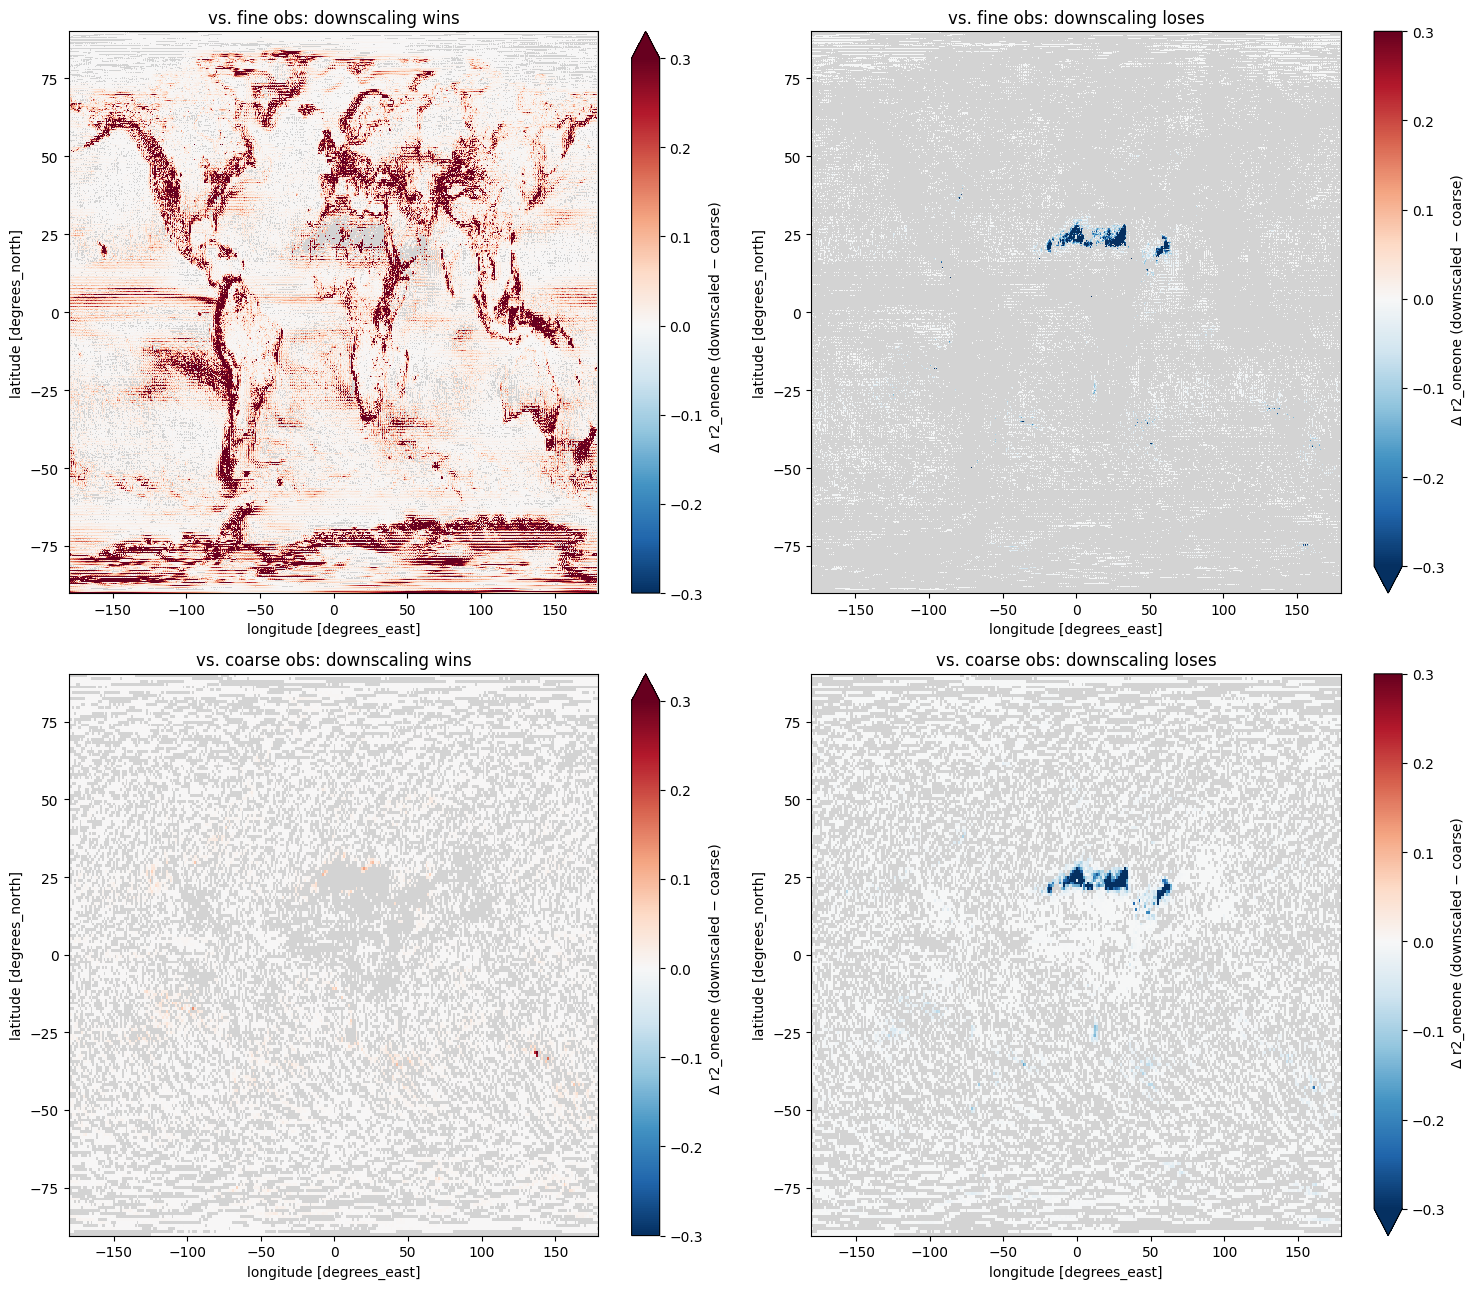

In [10]:
downscaled_vs_coarse_debiased_obsfine = (
    metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]
)
downscaled_vs_coarse_debiased_obscoarse = (
    metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]
)

plt.figure(figsize=(15, 13))
ax = plt.subplot(2, 2, 1)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obsfine.where(downscaled_vs_coarse_debiased_obsfine > 0).plot(
    vmax=r2_diff_vmax, vmin=-r2_diff_vmax, cmap=plt.cm.RdBu_r, cbar_kwargs={"label": r2_diff_label}
)
plt.title("vs. fine obs: downscaling wins")
ax = plt.subplot(2, 2, 2)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obsfine.where(downscaled_vs_coarse_debiased_obsfine < 0).plot(
    vmax=r2_diff_vmax, vmin=-r2_diff_vmax, cmap=plt.cm.RdBu_r, cbar_kwargs={"label": r2_diff_label}
)
plt.title("vs. fine obs: downscaling loses")
ax = plt.subplot(2, 2, 3)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obscoarse.where(downscaled_vs_coarse_debiased_obscoarse > 0).plot(
    vmax=r2_diff_vmax, vmin=-r2_diff_vmax, cmap=plt.cm.RdBu_r, cbar_kwargs={"label": r2_diff_label}
)
plt.title("vs. coarse obs: downscaling wins")
ax = plt.subplot(2, 2, 4)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obscoarse.where(downscaled_vs_coarse_debiased_obscoarse < 0).plot(
    vmax=r2_diff_vmax, vmin=-r2_diff_vmax, cmap=plt.cm.RdBu_r, cbar_kwargs={"label": r2_diff_label}
)
plt.title("vs. coarse obs: downscaling loses")
plt.tight_layout()

## Summary: is downscaling actually helping?

Recap of the framing from the top: downscaling should improve fidelity to observations, especially fine-resolution obs. Below: for each obs comparison, the fraction of the domain where downscaled beats coarse (and vice versa), plus the domain-mean r2_oneone for all four combinations.

In [11]:
print("Bias relative to fine-scale observations: coarse debiased vs. downscaled")
print("Fraction of area where downscaled output looks better than coarse output:")
print((downscaled_vs_coarse_debiased_obsfine > 0).mean().values)
print("Fraction of area where coarse output looks better than downscaled output:")
print((downscaled_vs_coarse_debiased_obsfine < 0).mean().values)
print("------------------")
print("Bias relative to coarse-scale observations: coarse debiased vs. downscaled")
print("Fraction of area where downscaled output looks better than coarse output:")
print((downscaled_vs_coarse_debiased_obscoarse > 0).mean().values)
print("Fraction of area where coarse output looks better than downscaled output:")
print((downscaled_vs_coarse_debiased_obscoarse < 0).mean().values)
print("------------------")
print("Domain-mean r2_oneone")
print("Fine obs vs. downscaled output:  ", metrics_obsfine_outputfine["r2_oneone"].mean().values)
print("Fine obs vs. coarse output:      ", metrics_obsfine_outputcoarse["r2_oneone"].mean().values)
print("Coarse obs vs. downscaled output:", metrics_obscoarse_outputfine["r2_oneone"].mean().values)
print(
    "Coarse obs vs. coarse output:    ", metrics_obscoarse_outputcoarse["r2_oneone"].mean().values
)

Bias relative to fine-scale observations: coarse debiased vs. downscaled
Fraction of area where downscaled output looks better than coarse output:
0.8985263522884882
Fraction of area where coarse output looks better than downscaled output:
0.09869009092310063
------------------
Bias relative to coarse-scale observations: coarse debiased vs. downscaled
Fraction of area where downscaled output looks better than coarse output:
0.5368381076388888
Fraction of area where coarse output looks better than downscaled output:
0.46314380787037035
------------------
Domain-mean r2_oneone
Fine obs vs. downscaled output:   0.9602577
Fine obs vs. coarse output:       0.82276344
Coarse obs vs. downscaled output: 0.96296334
Coarse obs vs. coarse output:     0.96485627


## Example: zoom into one point

A quick qualitative sanity check before looking at the maps -- the seasonal cycle of obs vs. each output at a single point (`pt_lat`, `pt_lon`, set in Configuration above).

In [12]:
# --- Point of interest
# [pt_lat,pt_lon]=[37.5, -79] #Southeastern US with low R2 (but downscaling improves)
[pt_lat, pt_lon] = [23, 30]  # Sahara (downscaling hurts rather than helps)

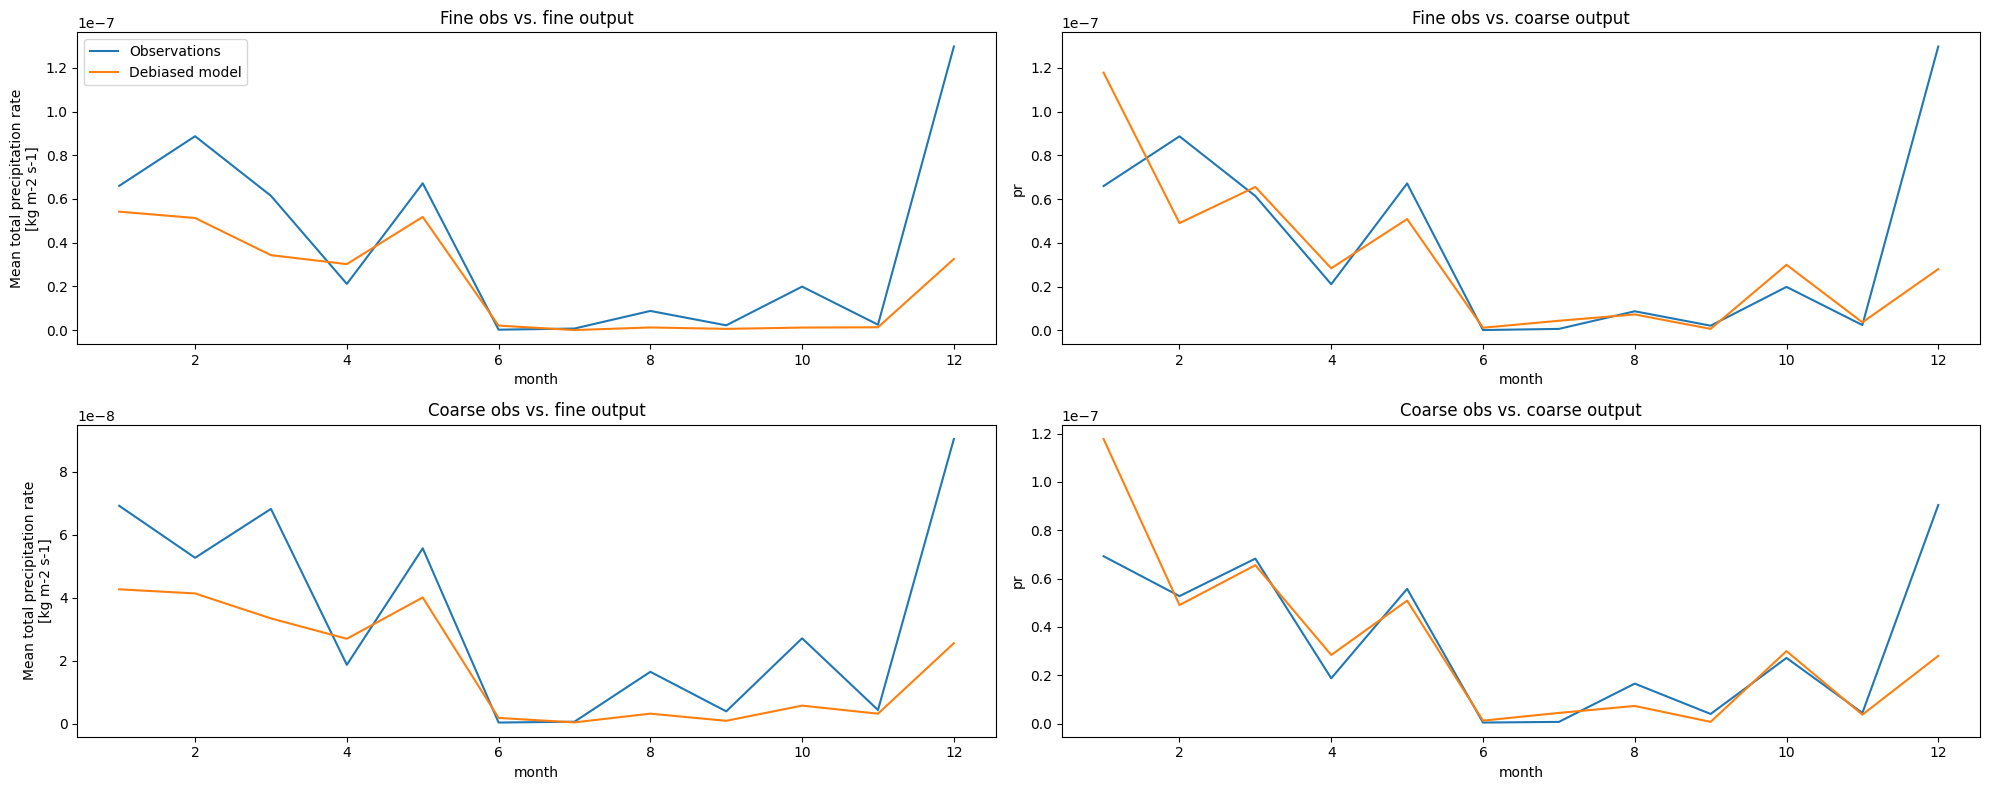

In [13]:
plt.figure(figsize=(20, 8))
plt.subplot(2, 2, 1)
obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Observations")
debiased_downscaled_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Debiased model")
plt.legend()
plt.title("Fine obs vs. fine output")
plt.subplot(2, 2, 2)
obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
coarse_debiased_finegrid_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
plt.title("Fine obs vs. coarse output")
plt.subplot(2, 2, 3)
obs_coarse_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
coarsened_debiased_downscaled_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
plt.title("Coarse obs vs. fine output")
plt.subplot(2, 2, 4)
obs_coarse_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
coarse_debiased_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
plt.title("Coarse obs vs. coarse output")
plt.tight_layout()

Text(0, 0.5, 'Debiased value')

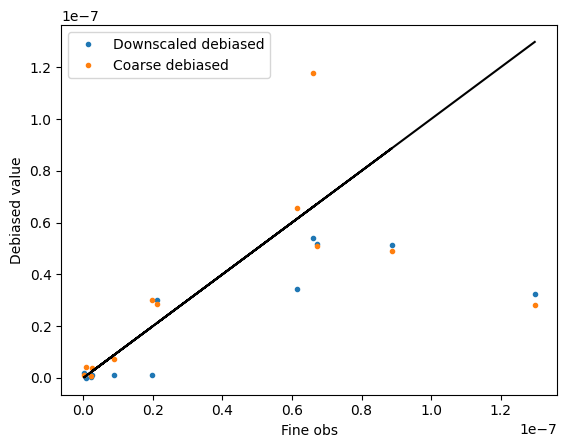

In [14]:
plt.plot(
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    debiased_downscaled_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    label="Downscaled debiased",
)
plt.plot(
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    coarse_debiased_finegrid_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    label="Coarse debiased",
)
plt.plot(
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    "-k",
)
plt.legend()
plt.xlabel("Fine obs")
plt.ylabel("Debiased value")

## Save results to CSV

In [15]:
def save_downscaling_improvement_csv(
    metrics_obsfine_outputfine,
    metrics_obsfine_outputcoarse,
    metrics_obscoarse_outputfine,
    metrics_obscoarse_outputcoarse,
    variable,
    scenario,
    ensemble_member,
    csv_path,
):
    """Summarize downscaled-vs-coarse skill (relative to fine and coarse obs) as a long-format CSV."""
    diff_obsfine = (
        metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]
    )
    diff_obscoarse = (
        metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]
    )

    rows = [
        # relative to fine obs
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_downscaled_better",
            "value": float((diff_obsfine > 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_coarse_better",
            "value": float((diff_obsfine < 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_same",
            "value": float((diff_obsfine == 0).mean().values),
        },
        # relative to coarse obs
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_downscaled_better",
            "value": float((diff_obscoarse > 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_coarse_better",
            "value": float((diff_obscoarse < 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_same",
            "value": float((diff_obscoarse == 0).mean().values),
        },
        # absolute r2 values
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "mean_r2_outputfine",
            "value": float(metrics_obsfine_outputfine["r2_oneone"].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "mean_r2_outputcoarse",
            "value": float(metrics_obsfine_outputcoarse["r2_oneone"].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "mean_r2_outputfine",
            "value": float(metrics_obscoarse_outputfine["r2_oneone"].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "mean_r2_outputcoarse",
            "value": float(metrics_obscoarse_outputcoarse["r2_oneone"].mean().values),
        },
    ]

    pd.DataFrame(rows).to_csv(csv_path, mode="w", index=False)

In [16]:
save_downscaling_improvement_csv(
    metrics_obsfine_outputfine=metrics_obsfine_outputfine,
    metrics_obsfine_outputcoarse=metrics_obsfine_outputcoarse,
    metrics_obscoarse_outputfine=metrics_obscoarse_outputfine,
    metrics_obscoarse_outputcoarse=metrics_obscoarse_outputcoarse,
    variable=var,
    scenario=scenario,
    ensemble_member=ens,
    csv_path=path_qaqc + "hist_bias_comparison_" + var + "_" + scenario + "_" + ens + ".csv",
)